<a href="https://colab.research.google.com/github/AivinBinoy/AivinBinoy/blob/main/Task_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Diabetes Prediction using Machine Learning

## 🎯 Objective
To predict whether a patient has diabetes using SVM and KNN models and compare their performance.

## 📊 Models Used
- Support Vector Machine (Linear, RBF, Sigmoid, Polynomial)
- K-Nearest Neighbors (KNN)

## 👤 Submitted By
Aivin Binoy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Loading the Dataset

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 3️⃣ Data Preprocessing

Handling zero values in important columns.

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

# 4️⃣ Splitting Features and Target

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 5️⃣ Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6️⃣ Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7️⃣ Training SVM Models

In [ ]:
kernels = ['linear', 'rbf', 'sigmoid', 'poly']
svm_results = {}

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    svm_results[kernel] = acc

    print(f"SVM ({kernel}) Accuracy:", acc)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))
    print("-"*40)

SVM (linear) Accuracy: 0.7662337662337663
[[83 16]
 [20 35]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154

----------------------------------------
SVM (rbf) Accuracy: 0.7532467532467533
[[84 15]
 [23 32]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        99
           1       0.68      0.58      0.63        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

----------------------------------------
SVM (sigmoid) Accuracy: 0.6948051948051948
[[80 19]
 [28 27]]
              precision    recall  f1-score   support

           0       0.74     

# 8️⃣ KNN - Elbow Method

In [ ]:
error = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error.append(np.mean(pred != y_test))

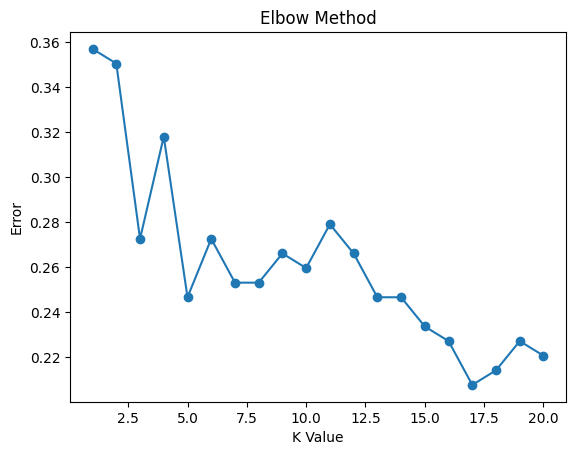

In [ ]:
plt.figure()
plt.plot(range(1, 21), error, marker='o')
plt.title('Elbow Method')
plt.xlabel('K Value')
plt.ylabel('Error')
plt.show()

# 9️⃣ Final KNN Model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred_knn))
print(confusion_matrix(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

KNN Accuracy: 0.7532467532467533
[[80 19]
 [19 36]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



# 🔟 Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF', 'SVM Sigmoid', 'SVM Poly', 'KNN'],
    'Accuracy': [
        svm_results['linear'],
        svm_results['rbf'],
        svm_results['sigmoid'],
        svm_results['poly'],
        accuracy_score(y_test, pred_knn)
    ]
})

results

,Model,Accuracy
0,SVM Linear,0.766234
1,SVM RBF,0.753247
2,SVM Sigmoid,0.694805
3,SVM Poly,0.746753
4,KNN,0.753247


## 🔍 Observations

- SVM models performed better for this dataset
- RBF kernel captured non-linear relationships effectively
- Sigmoid kernel gave lower performance
- KNN performance depends on K value
- Elbow method helped choose optimal K

## ✅ Conclusion

The diabetes prediction task was successfully completed using SVM and KNN models.  

SVM with RBF kernel showed better performance due to its ability to handle complex patterns.  
KNN performance improved after selecting the optimal K value using the Elbow Method.  

Thus, SVM is more effective for this dataset.